In [1]:
import torch
from torch import nn
from utils import spy
from utils.spy import Seq2SeqAttentionDecoder, Seq2SeqEncoder, MachineTranslation, Seq2Seq, Trainer, bleu

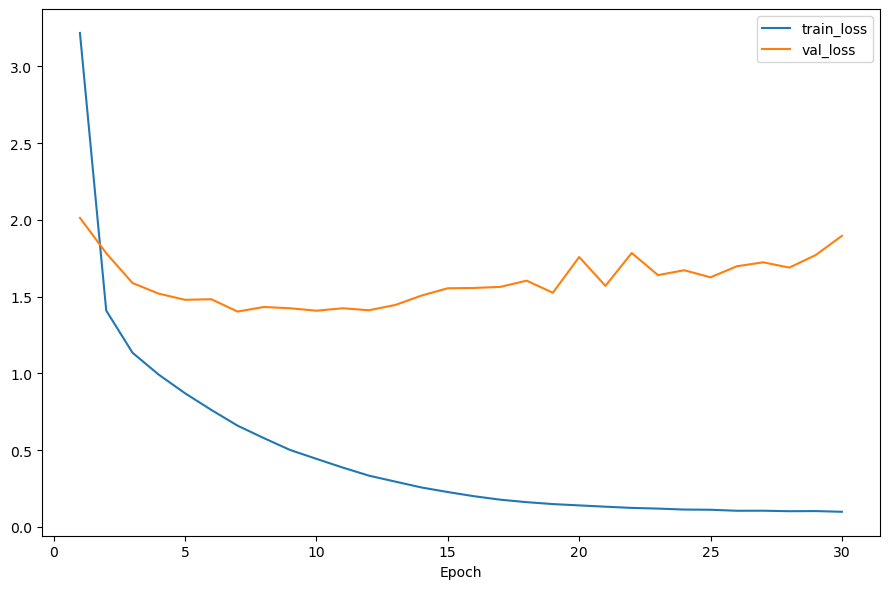

In [2]:
PATH = '../data/fra-eng/fra.txt'
data = MachineTranslation(PATH, batch_size=128)
embed_size, num_hiddens, num_layers, dropout = 256, 256, 2, 0.2
encoder = Seq2SeqEncoder(
    len(data.src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(
    len(data.tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
model = Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                    lr=0.005)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
trainer = Trainer(max_epochs=30, gradient_clip_val=1, device=device)
trainer.fit(model, data)

In [4]:
print(model.board['train_loss'][-1])

0.10163995064795017


In [5]:
print(model.board['val_loss'][-1])

1.8592870235443115


In [ ]:
from utils import spy

engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
preds, _ = model.predict_step(
    data.build(engs, fras), device, data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation} - bleu: '
          f'{spy.bleu(" ".join(translation), fr, k=2):.3f}')

go . => ['va', '!'], bleu,1.000
i lost . => ["j'ai", 'perdu', '.'], bleu,1.000
he's calm . => ['soyez', 'calme', '.'], bleu,0.492
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu,1.000


In [5]:
num_hiddens, num_heads = 100, 5
attention = spy.MultiHeadAttention(num_hiddens, num_heads, dropout=0.5)
batch_size, num_queries, num_kvpairs = 2, 4, 6
valid_lens = torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
spy.check_shape(attention(X, Y, Y, valid_lens),
                (batch_size, num_queries, num_hiddens))

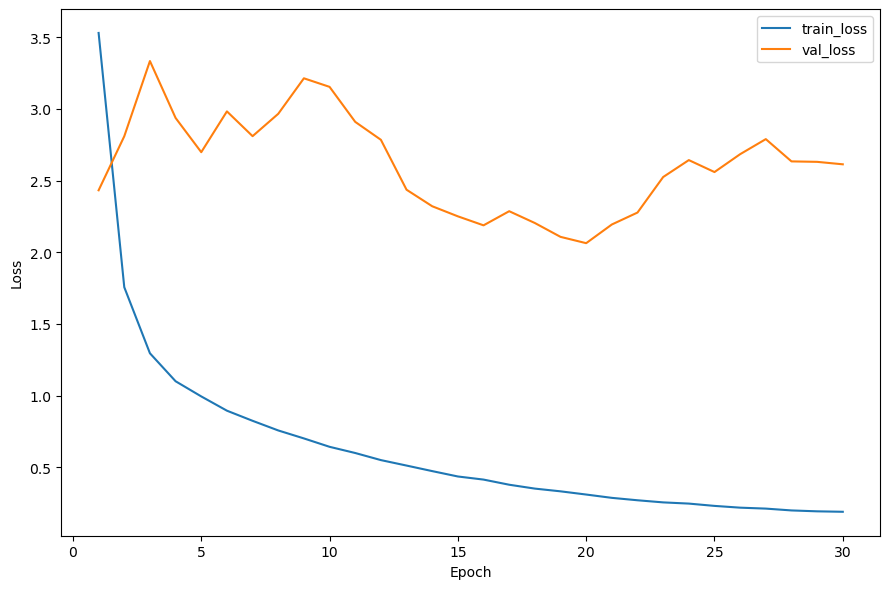

In [2]:
PATH = '../data/fra-eng/fra.txt'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

data = MachineTranslation(PATH, batch_size=128)
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 64, 4
encoder = spy.TransformerEncoder(
    len(data.src_vocab), num_hiddens, ffn_num_hiddens, num_heads,
    num_blks, dropout)
decoder = spy.TransformerDecoder(
    len(data.tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads,
    num_blks, dropout)
model = spy.Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                    lr=0.001)
trainer = spy.Trainer(max_epochs=30, gradient_clip_val=1, device=device)
trainer.fit(model, data)

In [5]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
preds, _ = model.predict_step(
    data.build(engs, fras), device, data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{spy.bleu(" ".join(translation), fr, k=2):.3f}')

go . => ['va', '!'], bleu,1.000
i lost . => ['je', 'suis', 'perdu', '.'], bleu,0.537
he's calm . => ['il', 'est', 'mouillé', '.'], bleu,0.658
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu,1.000


In [1]:
from utils import spy
import torch

In [2]:

img_size, patch_size, num_hiddens, batch_size = 96, 16, 512, 4
patch_emb = spy.PatchEmbedding(img_size, patch_size, num_hiddens)
X = torch.zeros(batch_size, 3, img_size, img_size)
spy.check_shape(patch_emb(X),
                (batch_size, (img_size//patch_size)**2, num_hiddens))

In [3]:
X = torch.ones((2, 100, 24))
encoder_blk = spy.ViTBlock(24, 24, 48, 8, 0.5)
encoder_blk.eval()
spy.check_shape(encoder_blk(X), X.shape)